In [1]:
import numpy as np
import VBMicrolensing
import matplotlib.pyplot as plt
import math

In [2]:
import numpy as np

# ---------- Core single-lens pieces ----------
def A_u(u):
    """Total magnification for a point source at separation u (in θ_E units)."""
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

def centroid_shift_single(u_vec):
    """
    Single-lens centroid shift vector δθ (in θ_E units) relative to the unlensed source position.
    δθ = [u/(u^2+2)] * û  (standard result), so vector form is u_vec/(u^2+2).
    """
    u = np.linalg.norm(u_vec, axis=-1, keepdims=True)
    return u_vec / (u**2 + 2)

# ---------- Binary-source centroid (single lens) ----------
def binary_source_centroid_shift(
    t, tE, 
    u01, t01,  # source 1 impact param & closest-approach time
    u02, t02,  # source 2 impact param & closest-approach time
    FR=1.0,    # F2/F1 baseline flux ratio
    thetaE_mas=None  # if provided, returns mas & µas columns too
):
    """
    Returns dict with:
      'x_shift','y_shift' (centroid shift of lensed system relative to unlensed binary COL) in θ_E units,
      'shift' (magnitude), plus optional 'shift_mas','shift_uas' if thetaE_mas is set.
    Assumes straight-line trajectories along +x with impact parameters along +y.
    """
    # Unlensed source positions relative to lens (θ_E units)
    x1 = (t - t01)/tE;  y1 = np.full_like(x1, u01)
    x2 = (t - t02)/tE;  y2 = np.full_like(x2, u02)
    s1 = np.stack([x1, y1], axis=-1)
    s2 = np.stack([x2, y2], axis=-1)

    # Magnifications for each source
    u1 = np.linalg.norm(s1, axis=-1)
    u2 = np.linalg.norm(s2, axis=-1)
    A1 = A_u(u1);  A2 = A_u(u2)

    # Centroid (lensed) of each source = source position + single-source centroid shift
    d1 = centroid_shift_single(s1)     # δθ_1
    d2 = centroid_shift_single(s2)     # δθ_2
    c1 = s1 + d1                       # θ_c1 (vector, rel. to lens)
    c2 = s2 + d2                       # θ_c2

    # Flux weights (baseline F1=1, F2=FR); lensed flux = F_i * A_i
    F1, F2 = 1.0, FR
    Flens1 = F1 * A1
    Flens2 = F2 * A2
    Ftot_lensed = Flens1 + Flens2

    # Observed lensed centroid of the system (vector, rel. to lens)
    c_obs = (Flens1[..., None]*c1 + Flens2[..., None]*c2) / Ftot_lensed[..., None]

    # Baseline (unlensed) center-of-light of the binary (vector, rel. to lens)
    c_base = (F1*s1 + F2*s2) / (F1 + F2)

    # Desired centroid shift of the binary system (vector) relative to baseline COL
    d_sys = c_obs - c_base

    out = {
        "x_shift": d_sys[..., 0],
        "y_shift": d_sys[..., 1],
        "shift":   np.linalg.norm(d_sys, axis=-1),
        "t":       t
    }
    if thetaE_mas is not None:
        out["shift_mas"] = out["shift"] * thetaE_mas
        out["shift_uas"] = out["shift_mas"] * 1000.0
    return out

# ---------- Example usage ----------
if __name__ == "__main__":
    # Example params (edit to your case)
    tE   = 37.3
    FR   = 0.4
    u01, t01 = 0.10, 7550.4
    u02, t02 = 0.05, 7555.8
    thetaE_mas = 0.5  # optional: θ_E = 0.5 mas (example)

    t = np.linspace(t01 - tE, t01 + tE, 600)

    res = binary_source_centroid_shift(t, tE, u01, t01, u02, t02, FR=FR, thetaE_mas=thetaE_mas)

    # Example: access arrays
    # res["x_shift"], res["y_shift"], res["shift"]  (in θ_E)
    # res["shift_mas"], res["shift_uas"]           (if thetaE_mas provided)
    # You can now plot res["t"] vs res["shift_uas"] for detectability against Roman.
    pass


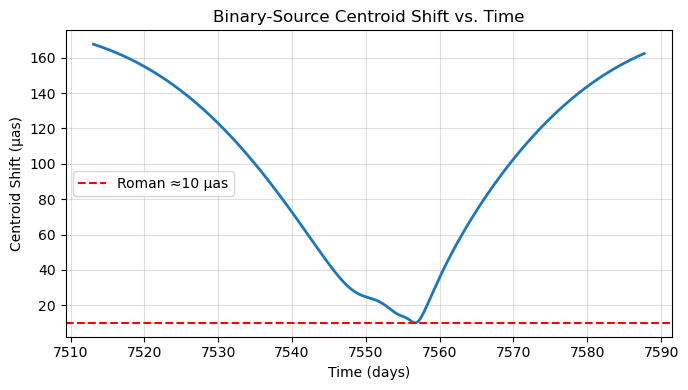

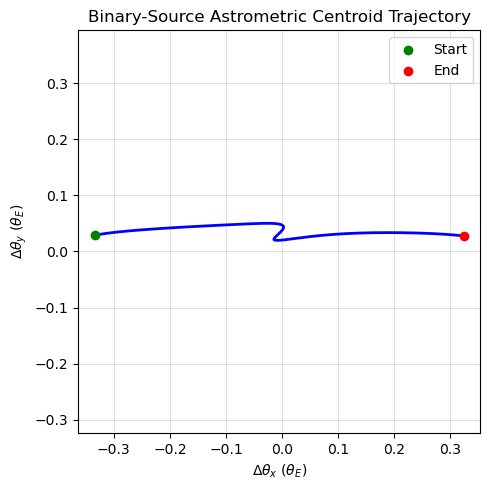

In [3]:
import matplotlib.pyplot as plt

# --- Run the centroid shift function first ---
res = binary_source_centroid_shift(t, tE, u01, t01, u02, t02, FR=FR, thetaE_mas=thetaE_mas)

# --- Plot 1: centroid shift magnitude vs. time ---
plt.figure(figsize=(7,4))
plt.plot(res["t"], res["shift_uas"], lw=2)
plt.axhline(10, color='r', ls='--', label="Roman ≈10 µas")
plt.xlabel("Time (days)")
plt.ylabel("Centroid Shift (µas)")
plt.title("Binary-Source Centroid Shift vs. Time")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# --- Plot 2: 2D centroid trajectory (in θE units) ---
plt.figure(figsize=(5,5))
plt.plot(res["x_shift"], res["y_shift"], lw=2, color='blue')
plt.scatter(res["x_shift"][0], res["y_shift"][0], color='green', label='Start', zorder=3)
plt.scatter(res["x_shift"][-1], res["y_shift"][-1], color='red', label='End', zorder=3)
plt.xlabel(r"$\Delta \theta_x$ ($\theta_E$)")
plt.ylabel(r"$\Delta \theta_y$ ($\theta_E$)")
plt.title("Binary-Source Astrometric Centroid Trajectory")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [4]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [5]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- (A) Single-lens, binary-source centroid (1L2S) ----------
def A_u(u):
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

def centroid_shift_single(u_vec):
    u = np.linalg.norm(u_vec, axis=-1, keepdims=True)
    return u_vec / (u**2 + 2)

def binary_source_centroid_shift_1L2S(t, tE, u01, t01, u02, t02, FR=1.0, thetaE_mas=None):
    x1 = (t - t01)/tE;  y1 = np.full_like(x1, u01)
    x2 = (t - t02)/tE;  y2 = np.full_like(x2, u02)
    s1 = np.stack([x1, y1], axis=-1)
    s2 = np.stack([x2, y2], axis=-1)

    A1 = A_u(np.linalg.norm(s1, axis=-1))
    A2 = A_u(np.linalg.norm(s2, axis_-1))

    d1 = centroid_shift_single(s1)    # δθ_1 in θE
    d2 = centroid_shift_single(s2)    # δθ_2 in θE
    c1 = s1 + d1                      # lensed centroid of source 1 (rel. to lens)
    c2 = s2 + d2

    F1, F2 = 1.0, FR
    Fl1, Fl2 = F1*A1, F2*A2
    c_obs = (Fl1[...,None]*c1 + Fl2[...,None]*c2) / (Fl1+Fl2)[...,None]

    c_base = (F1*s1 + F2*s2) / (F1+F2)  # unlensed binary COL
    d_sys = c_obs - c_base              # desired shift (θE)

    out = {"x": d_sys[...,0], "y": d_sys[...,1], "mag": np.linalg.norm(d_sys, axis=-1), "t": t}
    if thetaE_mas is not None:
        out["mag_mas"] = out["mag"]*thetaE_mas
        out["mag_uas"] = out["mag_mas"]*1000.0
    return out

# ---------- (B) Binary-lens, single-source centroid (2L1S) ----------
# We compute the centroid from image positions & magnifications: 
#   θ_cent = Σ(μ_i * θ_i) / Σ μ_i ; shift = θ_cent - θ_source  (all in θE)
#
# Provide a solver callback that returns images for a given source position.
# Fill this with your actual VBM call (or TripleLensing), returning (x_img, y_img, mu_img) arrays.

def compute_centroid_from_images(xs, ys, image_solver):
    """
    xs, ys: arrays (same shape) of source positions in θE (relative to lens COM)
    image_solver: function(xs_k, ys_k) -> (x_imgs, y_imgs, mu_imgs) for one epoch
    returns: (dx, dy) centroid shift arrays in θE
    """
    dx = np.zeros_like(xs, dtype=float)
    dy = np.zeros_like(ys, dtype=float)
    for k, (xk, yk) in enumerate(zip(xs, ys)):
        xi, yi, mui = image_solver(xk, yk)     # <-- YOU implement with VBM
        mui = np.asarray(mui)
        Xi = np.asarray(xi); Yi = np.asarray(yi)

        # lensed centroid (relative to lens)
        cx = np.sum(mui*Xi)/np.sum(mui)
        cy = np.sum(mui*Yi)/np.sum(mui)
        # unlensed source position is (xk, yk)
        dx[k] = cx - xk
        dy[k] = cy - yk
    return dx, dy

def binary_lens_centroid_2L1S(times, tE, u0, t0, alpha_deg, image_solver, thetaE_mas=None):
    """
    times: array (same grid as triple_model.highres_t)
    u0, t0: standard closest-approach param (impact param & epoch) in θE and days
    alpha_deg: trajectory angle of source motion (0° along +x)
    image_solver(xs, ys) must return images for the current binary-lens model (your VBM setup).
    """
    alpha = np.deg2rad(alpha_deg)
    # straight-line trajectory rotated by alpha
    tau = (times - t0)/tE
    xs =  tau*np.cos(alpha) - u0*np.sin(alpha)
    ys =  tau*np.sin(alpha) + u0*np.cos(alpha)

    dx, dy = compute_centroid_from_images(xs, ys, image_solver)
    mag = np.hypot(dx, dy)
    out = {"x": dx, "y": dy, "mag": mag, "t": times}
    if thetaE_mas is not None:
        out["mag_mas"] = mag*thetaE_mas
        out["mag_uas"] = out["mag_mas"]*1000.0
    return out

# ---------- (C) Wire it to YOUR objects ----------
# You already have:
#   double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc=triple_model.highres_t)
#   A_bin = double_model.VBM.BinaryLightCurve([...], triple_model.highres_t)[0]
#
# Define the image_solver using your VBM instance. Replace the call inside with the
# correct VBM method that returns image positions & magnifications for the binary lens.

def image_solver_vbm(x_src, y_src):
    """
    Example placeholder — replace with your actual VBM image solver call for 2L1S.
    You need it to return arrays: (x_imgs, y_imgs, mu_imgs) in θE units.
    """
    # e.g., xi, yi, mui = double_model.VBM.BinaryImages(params..., x_src, y_src)
    # return xi, yi, mui
    raise NotImplementedError("Hook this to your VBM binary-lens image solver.")

# ---------- (D) Run both on the same grid & plot ----------
# Example params (edit to your case):
thetaE_mas = 0.5
# 0) one shared time grid for everything
t_grid = np.linspace(t0 - 1.5*tE, t0 + 1.5*tE, 1200)

# 1) 1L2S centroid on the same grid
res_1L2S = binary_source_centroid_shift_1L2S(
    t_grid, tE, u01, t01, u02, t02, FR=FR, thetaE_mas=thetaE_mas
)

# 2) Build your 2L1S model on the SAME grid (no triple_model needed)
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc=t_grid)
A_bin = double_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q4), u0_list[0], 0, np.log(rho), np.log(tE), t0], t_grid
)[0]

# 3) Image solver wrapper -> replace the VBM call with your real one
def image_solver_vbm(x_src, y_src):
    # Example placeholder — swap with your actual VBM 2L1S images API:
    # xi, yi, mui = double_model.VBM.BinaryImages([np.log(s2), np.log(q4), np.log(rho)], x_src, y_src)
    raise NotImplementedError

# 4) 2L1S centroid on the same grid
res_2L1S = binary_lens_centroid_2L1S(
    t_grid, tE, u0_list[0], t0, alpha_deg, image_solver_vbm, thetaE_mas=thetaE_mas
)

# 5) Plot both + residuals (unchanged)


# 1L2S:
FR   = 0.4
u01, t01 = 0.10, t_grid[len(t_grid)//2] - 2.0
u02, t02 = 0.05, t_grid[len(t_grid)//2] + 2.0
res_1L2S = binary_source_centroid_shift_1L2S(t_grid, tE, u01, t01, u02, t02, FR=FR, thetaE_mas=thetaE_mas)

# 2L1S (needs your VBM image solver):
u0_2L1S   = 0.08
alpha_deg = 25.0
res_2L1S = binary_lens_centroid_2L1S(t_grid, tE, u0_2L1S, t0, alpha_deg, image_solver_vbm, thetaE_mas=thetaE_mas)

# Photometry (you already computed A_bin); here’s a safe guard if you need normalization
# A_bin_norm = A_bin / np.median(A_bin[(t_grid < t0 - 3*tE) | (t_grid > t0 + 3*tE)])

# ---------- Plots ----------
# (1) Centroid magnitude vs time (µas)
plt.figure(figsize=(7,4))
plt.plot(res_2L1S["t"], res_2L1S["mag_uas"], lw=2, label="2L1S")
plt.plot(res_1L2S["t"], res_1L2S["mag_uas"], lw=2, label="1L2S")
plt.axhline(10, ls="--", label="Roman ≈10 µas")
plt.xlabel("Time (days)")
plt.ylabel("Centroid Shift (µas)")
plt.title("Astrometric Centroid: 2L1S vs 1L2S")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

# (2) Residuals (2L1S − 1L2S) in µas
plt.figure(figsize=(7,4))
plt.plot(t_grid, res_2L1S["mag_uas"] - res_1L2S["mag_uas"], lw=2)
plt.axhline(0, ls=":"); plt.xlabel("Time (days)")
plt.ylabel("Δ Centroid (µas)")
plt.title("Centroid Residuals (2L1S − 1L2S)")
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


NameError: name 'triple_model' is not defined

In [12]:
import numpy as np

# ----------- Time grid -----------
t0   = 0.0
tE   = 30.0                 # days
t_grid = np.linspace(t0 - 1.5*tE, t0 + 1.5*tE, 1200)

# ----------- 1L2S (single lens, binary source) -----------
# impact params & epochs for the two sources (θ_E units & days)
u01, t01 = 0.10, t0 - 2.0
u02, t02 = 0.06, t0 + 2.0
FR       = 0.4              # F2/F1 baseline flux ratio
thetaE_mas = 0.5            # if you want µas outputs

# now you can call your 1L2S function from earlier:
res_1L2S = binary_source_centroid_shift(
    t_grid, tE, u01, t01, u02, t02, FR=FR, thetaE_mas=thetaE_mas
)

# ----------- 2L1S (binary lens, single source) -----------
# lens params (typical demo values)
s2  = 1.30                  # star–planet separation in θ_E
q4  = 1.0e-3                # mass ratio (Jupiter-like)
rho = 1.0e-3                # source radius in θ_E
u0_list = [0.08]            # impact parameter for source
alpha_deg = 25.0            # trajectory angle

# build your photometry model on the SAME grid (your example call)
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc=t_grid)
A_bin = double_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q4), u0_list[0], 0, np.log(rho), np.log(tE), t0],
    t_grid
)[0]

# For the 2L1S **centroid**, you’ll need an images call from your VBM binding.
# If your API exposes something like BinaryImages(...), wire it here:
def image_solver_vbm(x_src, y_src):
    # xi, yi, mui = double_model.VBM.BinaryImages([np.log(s2), np.log(q4), np.log(rho)], x_src, y_src)
    # return xi, yi, mui
    raise NotImplementedError("Replace with your VBM call that returns image positions & magnifications.")

# Then compute 2L1S centroid (same grid):
res_2L1S = binary_lens_centroid_2L1S(t_grid, tE, u0_list[0], t0, alpha_deg, image_solver_vbm, thetaE_mas=thetaE_mas)


NotImplementedError: Replace with your VBM call that returns image positions & magnifications.

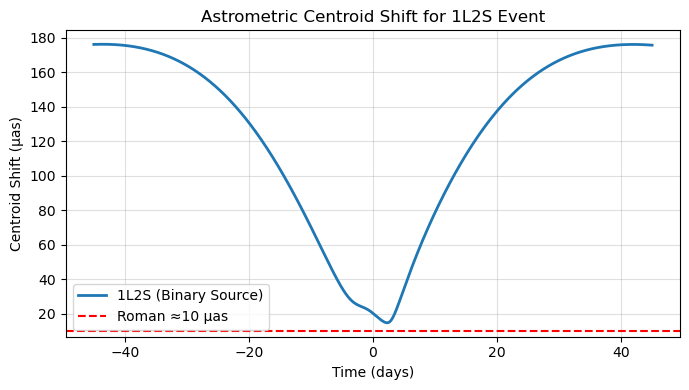

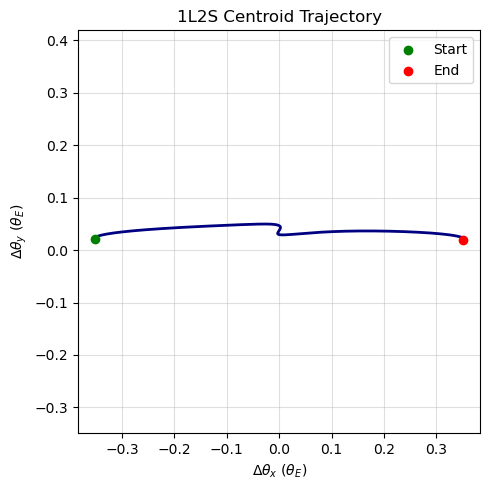

In [10]:
# --- 1L2S centroid simulation ---
res_1L2S = binary_source_centroid_shift(
    t_grid,       # same time array as 2L1S
    tE,           # Einstein timescale
    u01, t01,     # source 1 parameters
    u02, t02,     # source 2 parameters
    FR=FR,        # flux ratio (F2/F1)
    thetaE_mas=thetaE_mas
)

# --- Plot centroid shift vs time ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(res_1L2S["t"], res_1L2S["shift_uas"], lw=2, label="1L2S (Binary Source)")
plt.axhline(10, color='r', ls='--', label="Roman ≈10 µas")
plt.xlabel("Time (days)")
plt.ylabel("Centroid Shift (µas)")
plt.title("Astrometric Centroid Shift for 1L2S Event")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# --- Plot centroid trajectory ---
plt.figure(figsize=(5,5))
plt.plot(res_1L2S["x_shift"], res_1L2S["y_shift"], lw=2, color='navy')
plt.scatter(res_1L2S["x_shift"][0], res_1L2S["y_shift"][0], color='green', label="Start", zorder=3)
plt.scatter(res_1L2S["x_shift"][-1], res_1L2S["y_shift"][-1], color='red', label="End", zorder=3)
plt.xlabel(r"$\Delta \theta_x$ ($\theta_E$)")
plt.ylabel(r"$\Delta \theta_y$ ($\theta_E$)")
plt.title("1L2S Centroid Trajectory")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


NameError: name 'res_2L1S' is not defined

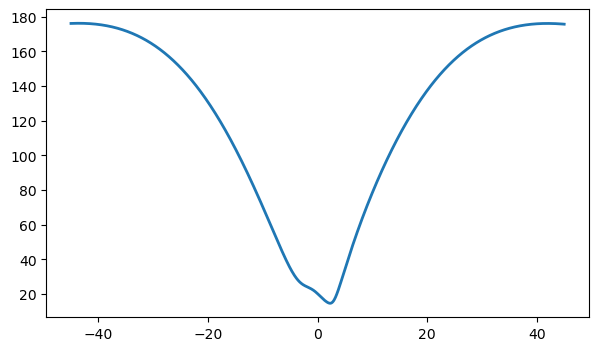

In [11]:
plt.figure(figsize=(7,4))
plt.plot(res_1L2S["t"], res_1L2S["shift_uas"], lw=2, label="1L2S (Binary Source)")
plt.plot(res_2L1S["t"], res_2L1S["mag_uas"], lw=2, label="2L1S (Binary Lens)")
plt.axhline(10, color='r', ls='--', label="Roman ≈10 µas")
plt.xlabel("Time (days)")
plt.ylabel("Centroid Shift (µas)")
plt.title("Astrometric Centroid Shift: 1L2S vs 2L1S")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


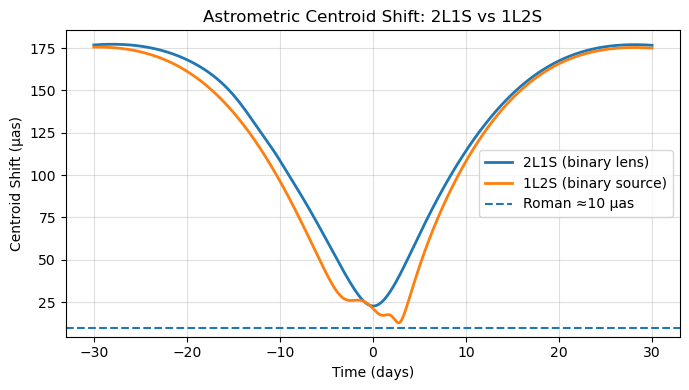

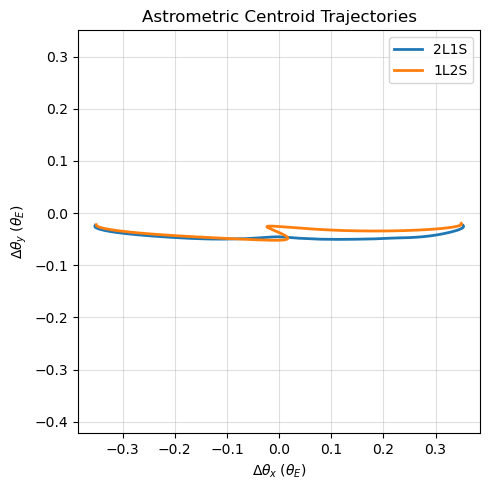

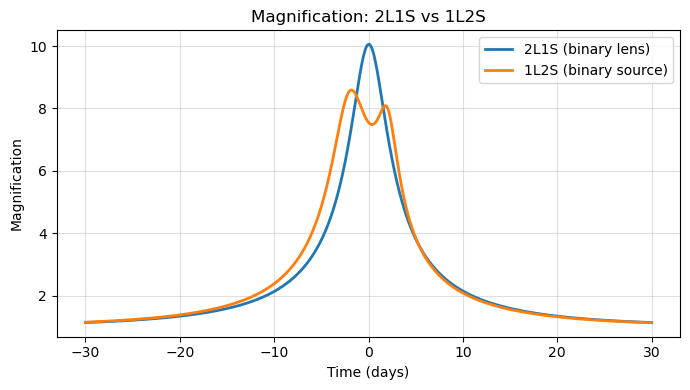

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 0) SHARED PARAMS ==========
t0   = 0.0
tE   = 20                                # days
t    = np.linspace(t0 - 1.5*tE, t0 + 1.5*tE, 1200)  # one common time grid
thetaE_mas = 0.5                             # θ_E for scaling to µas (edit as needed)

# ========== 1) 2L1S (Binary Lens, Single Source) ==========
# Lens params
s2   = 1.30
q4   = 0.0009523333333333334
rho  = 0.0018
u0_list = [0.1]
alpha_deg = 25  # if your model uses this elsewhere

# Build your binary-lens model on *the same* time grid
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc=t)

# Photometry (2L1S) via your VBM binding
A_2L1S = double_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q4), u0_list[0], 25, np.log(rho), np.log(tE), t0],
    t
)[0]

# Centroid shift (2L1S) from your systems dict
two_sys = double_model.systems[0]
dx_2 = two_sys['cent_x_lc'] - two_sys['y1s_lc']
dy_2 = two_sys['cent_y_lc'] - two_sys['y2s_lc']
mag_2 = np.hypot(dx_2, dy_2)
mag_2_uas = mag_2 * thetaE_mas * 1e3

# ========== 2) 1L2S (Single Lens, Binary Source) ==========
# Binary-source params (same grid)
u01, t01 = 0.10, t0 - 2.0   # source 1 impact & epoch
u02, t02 = 0.06, t0 + 2.0   # source 2 impact & epoch
FR       = 0.4              # baseline flux ratio F2/F1

def A_u(u):
    return (u**2 + 2.0) / (u * np.sqrt(u**2 + 4.0))

# Straight-line trajectories (x along motion, y is impact)
x1 = (t - t01)/tE;  y1 = np.full_like(x1, u01)
x2 = (t - t02)/tE;  y2 = np.full_like(x2, u02)
u1 = np.hypot(x1, y1); u2 = np.hypot(x2, y2)

# Photometry (1L2S) — flux-weighted single-lens
A1 = A_u(u1); A2 = A_u(u2)
A_1L2S = (A1 + FR*A2) / (1.0 + FR)

# Centroid (1L2S) — flux-weighted centroid of two single-lens shifts
def centroid_shift_single(u_vec):
    # u_vec shape (...,2)
    u = np.linalg.norm(u_vec, axis=-1, keepdims=True)
    return u_vec / (u**2 + 2.0)

s1 = np.stack([x1, y1], axis=-1)   # unlensed source 1 vector
s2 = np.stack([x2, y2], axis=-1)   # unlensed source 2 vector
d1 = centroid_shift_single(s1)     # δθ_1 in θ_E
d2 = centroid_shift_single(s2)     # δθ_2 in θ_E
c1 = s1 + d1                       # lensed centroid (rel. to lens)
c2 = s2 + d2

F1, F2 = 1.0, FR
Fl1, Fl2 = F1*A1, F2*A2
c_obs = (Fl1[...,None]*c1 + Fl2[...,None]*c2) / (Fl1 + Fl2)[...,None]     # lensed COL
c_base = (F1*s1 + F2*s2) / (F1 + F2)                                     # unlensed COL
d_bin  = c_obs - c_base                                                  # desired shift
dx_1 = d_bin[...,0]; dy_1 = -d_bin[...,1]
mag_1 = np.hypot(dx_1, dy_1)
mag_1_uas = mag_1 * thetaE_mas * 1e3

# ========== 3) PLOTS ==========
# (A) Centroid shift vs time (µas)
plt.figure(figsize=(7,4))
plt.plot(t, mag_2_uas, lw=2, label="2L1S (binary lens)")
plt.plot(t, mag_1_uas, lw=2, label="1L2S (binary source)")
plt.axhline(10, ls='--', label="Roman ≈10 µas")
plt.xlabel("Time (days)"); plt.ylabel("Centroid Shift (µas)")
plt.title("Astrometric Centroid Shift: 2L1S vs 1L2S")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

# (B) Centroid trajectories (θ_E)
plt.figure(figsize=(5,5))
plt.plot(dx_2, dy_2, lw=2, label="2L1S")
plt.plot(dx_1, dy_1, lw=2, label="1L2S")
plt.xlabel(r"$\Delta\theta_x\;(\theta_E)$"); plt.ylabel(r"$\Delta\theta_y\;(\theta_E)$")
plt.title("Astrometric Centroid Trajectories")
plt.axis('equal'); plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

# (C) Magnification vs time
plt.figure(figsize=(7,4))
plt.plot(t, A_2L1S, lw=2, label="2L1S (binary lens)")
plt.plot(t, A_1L2S, lw=2, label="1L2S (binary source)")
plt.xlabel("Time (days)"); plt.ylabel("Magnification")
plt.title("Magnification: 2L1S vs 1L2S")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


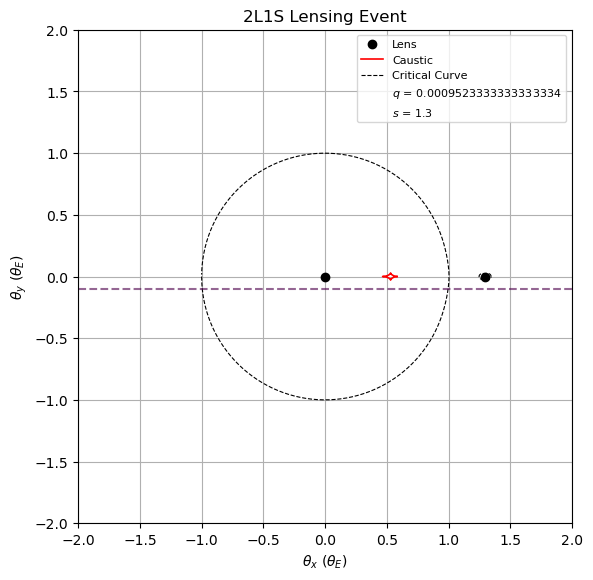

In [20]:

double_model.plot_caustic_critical_curves()

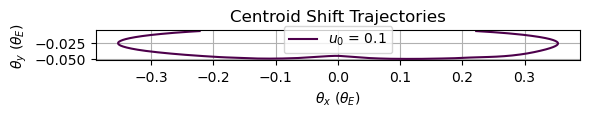

In [21]:
double_model.plot_centroid_trajectory()

In [22]:
m1 = 0.3 #Lens Star Mass (Solar Mass)
m2 = 0.0002857 #Lens Planet Mass (Saturn Mass in Solar Mass)
m3 = 3.003e-6 #Lens Moon (Earth Mass in Solas Mass)

M_total = m1 + m2+ m3

D_l = 7.59 #kpc
D_s = 8.55 #kpc

s2 = 1.3 #R_E (Star-Planet Separation)
d = 0.1 #R_E (Planet-Moon Separation)

q2 = m2/m1
q3 = m3/m1

print(q2, q3, m3/m1)

# Event parameters
t0 = 0
tE = 20
rho = 0.0018
rs = rho
u0_list = [0.1]


secnum = 45
basenum = 2
num_points = 1000

tau_lc = np.linspace(-4, 4, 1000)
t_lc = t0 + tau_lc * tE

0.0009523333333333334 1.001e-05 1.001e-05


In [23]:
double_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 25, t_lc)

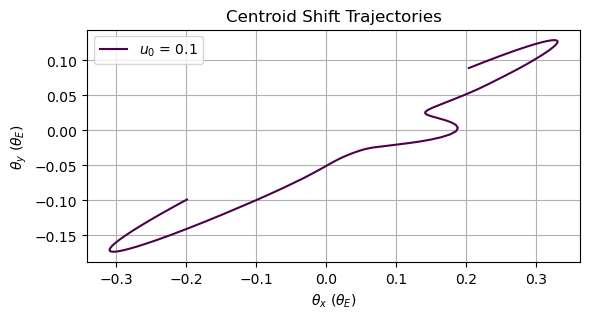

In [25]:
double_model.plot_centroid_trajectory()

q2 (planet/star) = 0.0009523333333333334   q3 (moon/star) = 1.001e-05
theta_E ≈ 0.190 mas


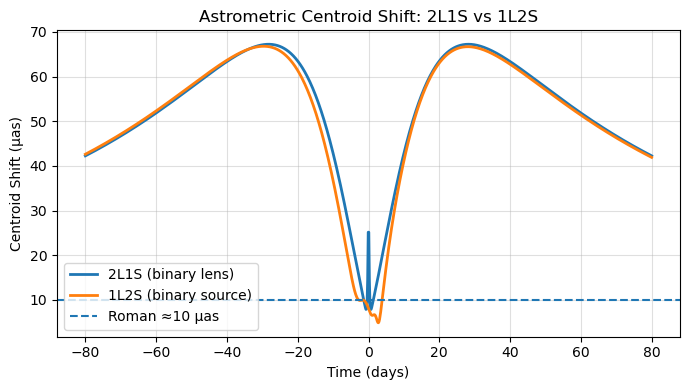

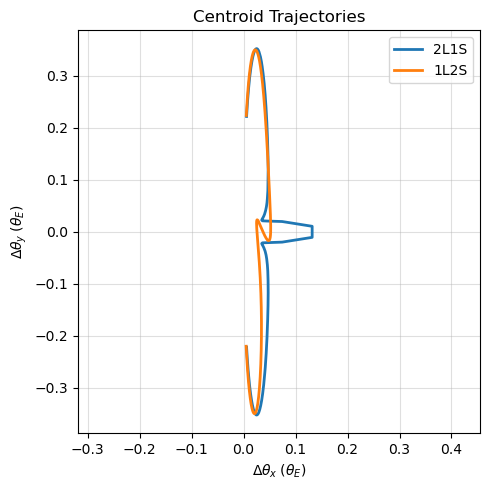

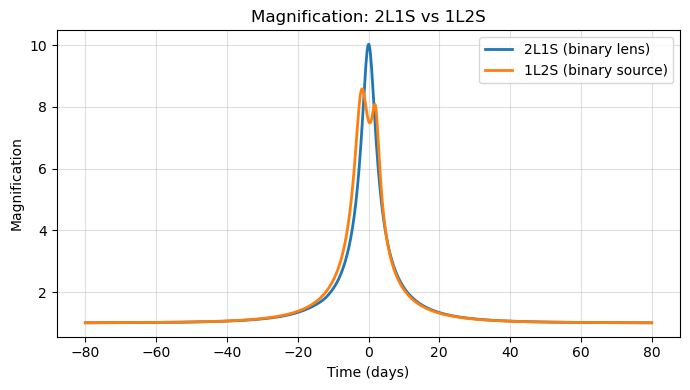

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Your parameters ====
m1 = 0.3          # Msun (lens star)
m2 = 0.0002857    # Msun (planet ~Saturn)
m3 = 3.003e-6     # Msun (moon ~Earth)
M_total = m1 + m2 + m3

D_l = 7.59  # kpc
D_s = 8.55  # kpc

s2 = 1.3    # star–planet separation (θE units)
d  = 0.1    # planet–moon separation (θE units)  # (unused for 2L1S/1L2S)

q2 = m2/m1
q3 = m3/m1
print("q2 (planet/star) =", q2, "  q3 (moon/star) =", q3)

# Event/grid
t0  = 0.0
tE  = 20.0
rho = 0.0018
u0_list = [0.10]

tau_lc = np.linspace(-4, 4, 1000)
t_lc   = t0 + tau_lc * tE   # shared time grid

# ==== θE (mas) from masses + distances ====
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
kpc   = 3.085677581491367e19
rad2mas = 206265000.0

M_kg = M_total * M_sun
D_l_m = D_l * kpc
D_s_m = D_s * kpc
D_ls_m = (D_s - D_l) * kpc

thetaE_rad = np.sqrt((4*G*M_kg/c**2) * (D_ls_m/(D_l_m*D_s_m)))
thetaE_mas = thetaE_rad * rad2mas
print(f"theta_E ≈ {thetaE_mas:.3f} mas")

# ==== Helpers for 1L (single lens) pieces ====
def A_u(u):
    return (u**2 + 2.0) / (u * np.sqrt(u**2 + 4.0))

def centroid_shift_single(u_vec):
    # u_vec shape (...,2), returns δθ in θE units
    u = np.linalg.norm(u_vec, axis=-1, keepdims=True)
    return u_vec / (u**2 + 2.0)

# =========================================================
# 1) 2L1S (binary lens, single source) using your class
# =========================================================
# Use q = planet/star for 2L1S
q = q2

double_model = TwoLens1S(t0, tE, rho, u0_list, q, s2, 90, t_lc=t_lc)

A_2L1S = double_model.VBM.BinaryLightCurve(
    [np.log(s2), np.log(q), u0_list[0], 0, np.log(rho), np.log(tE), t0],
    t_lc
)[0]

two_sys = double_model.systems[0]
dx_2 = two_sys['cent_x_lc'] - two_sys['y1s_lc']
dy_2 = two_sys['cent_y_lc'] - two_sys['y2s_lc']
mag_2 = np.hypot(dx_2, dy_2)
mag_2_uas = mag_2 * thetaE_mas * 1e3  # µas

# =========================================================
# 2) 1L2S (single lens, binary source) with same t0, tE, t_lc
# =========================================================
# same binary-source config
u01, t01 = 0.10, t0 - 2.0
u02, t02 = 0.06, t0 + 2.0
FR       = 0.4   # F2/F1

# --- rotate trajectories by alpha (e.g., 25°) ---
alpha_deg = 90          # match your 2L1S angle
alpha = np.deg2rad(alpha_deg)

tau1 = (t_lc - t01)/tE
tau2 = (t_lc - t02)/tE

x1 = tau1*np.cos(alpha) - u01*np.sin(alpha)
y1 = tau1*np.sin(alpha) + u01*np.cos(alpha)

x2 = tau2*np.cos(alpha) - u02*np.sin(alpha)
y2 = tau2*np.sin(alpha) + u02*np.cos(alpha)

# proceed as before
u1 = np.hypot(x1, y1); u2 = np.hypot(x2, y2)

A1 = A_u(u1); A2 = A_u(u2)
A_1L2S = (A1 + FR*A2) / (1.0 + FR)

s1 = np.stack([x1, y1], axis=-1)
s2v= np.stack([x2, y2], axis=-1)
d1 = centroid_shift_single(s1)
d2 = centroid_shift_single(s2v)
c1 = s1 + d1
c2 = s2v + d2

F1, F2 = 1.0, FR
Fl1, Fl2 = F1*A1, F2*A2
c_obs  = (Fl1[...,None]*c1 + Fl2[...,None]*c2) / (Fl1 + Fl2)[...,None]
c_base = (F1*s1 + F2*s2v) / (F1 + F2)
d_bin  = c_obs - c_base

dx_1 = -d_bin[...,0]; dy_1 = -d_bin[...,1]
mag_1 = np.hypot(dx_1, dy_1)
mag_1_uas = mag_1 * thetaE_mas * 1e3  # µas

# =========================================================
# 3) PLOTS
# =========================================================
# (A) Centroid shift vs time
plt.figure(figsize=(7,4))
plt.plot(t_lc, mag_2_uas, lw=2, label="2L1S (binary lens)")
plt.plot(t_lc, mag_1_uas, lw=2, label="1L2S (binary source)")
plt.axhline(10, ls='--', label="Roman ≈10 µas")
plt.xlabel("Time (days)"); plt.ylabel("Centroid Shift (µas)")
plt.title("Astrometric Centroid Shift: 2L1S vs 1L2S")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

# (B) Centroid trajectories
plt.figure(figsize=(5,5))
plt.plot(dx_2, dy_2, lw=2, label="2L1S")
plt.plot(dx_1, dy_1, lw=2, label="1L2S")
plt.xlabel(r"$\Delta\theta_x\;(\theta_E)$"); plt.ylabel(r"$\Delta\theta_y\;(\theta_E)$")
plt.title("Centroid Trajectories")
plt.axis('equal'); plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

# (C) Magnification
plt.figure(figsize=(7,4))
plt.plot(t_lc, A_2L1S, lw=2, label="2L1S (binary lens)")
plt.plot(t_lc, A_1L2S, lw=2, label="1L2S (binary source)")
plt.xlabel("Time (days)"); plt.ylabel("Magnification")
plt.title("Magnification: 2L1S vs 1L2S")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


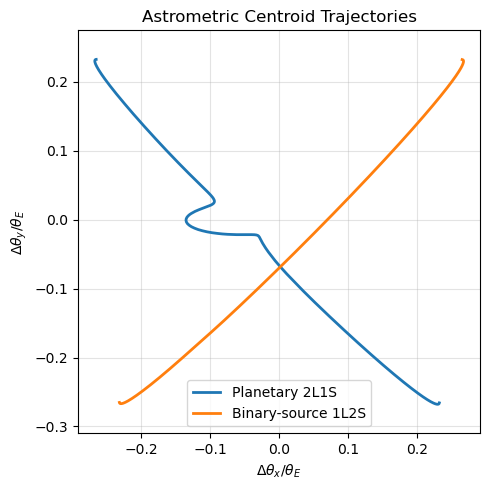

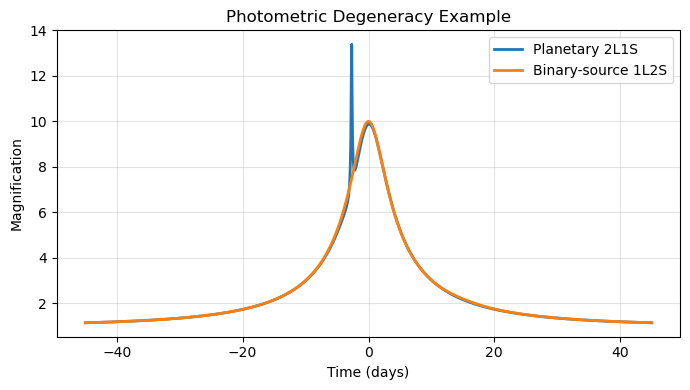

In [ ]:
# --- Shared choices (you can keep your current values) ---
t0, tE = 0.0, 30.0
u0     = 0.10
rho    = 1.0e-3
alpha_deg = 315
alpha = np.deg2rad(alpha_deg)
t     = np.linspace(t0-1.5*tE, t0+1.5*tE, 1200)

# ---------- Planetary case: 2L1S (match Han Fig. 1 planetary) ----------
q = 1.0e-3          # mass ratio
s = 1.183           # star–planet separation (in θ_E)
double_model = TwoLens1S(t0, tE, rho, [u0], q, s, 315, t_lc=t)
A_2L1S = double_model.VBM.BinaryLightCurve(
    [np.log(s), np.log(q), u0, 315, np.log(rho), np.log(tE), t0], t
)[0]
two_sys = double_model.systems[0]
dx_2 = two_sys['cent_x_lc'] - two_sys['y1s_lc']
dy_2 = two_sys['cent_y_lc'] - two_sys['y2s_lc']

# ---------- Binary-source case: 1L2S (match Han Fig. 1 binary-source) ----------
R = 5e-3            # flux ratio F2/F1
b = 0.5             # separation between sources (in θ_E)

# Implement b along the trajectory direction: time offset Δt = b * tE
u01, t01 = u0, t0
u02, t02 = u0, t0 + b*tE   # same impact param, shifted along-track by b

# Rotate both source trajectories by alpha (to match your 25° path)
tau1 = (t - t01)/tE
tau2 = (t - t02)/tE
x1 = tau1*np.cos(alpha) - u01*np.sin(alpha);  y1 = tau1*np.sin(alpha) + u01*np.cos(alpha)
x2 = tau2*np.cos(alpha) - u02*np.sin(alpha);  y2 = tau2*np.sin(alpha) + u02*np.cos(alpha)

def A_u(u): return (u**2+2)/(u*np.sqrt(u**2+4))
def centroid_shift_single(uvec):
    u = np.linalg.norm(uvec, axis=-1, keepdims=True)
    return uvec/(u**2+2)

u1, u2 = np.hypot(x1,y1), np.hypot(x2,y2)
A1, A2 = A_u(u1), A_u(u2)
A_1L2S = (A1 + R*A2)/(1+R)

s1 = np.stack([x1,y1], axis=-1); s2v = np.stack([x2,y2], axis=-1)
d1 = centroid_shift_single(s1);   d2 = centroid_shift_single(s2v)
c1 = s1 + d1;                     c2 = s2v + d2
F1, F2 = 1.0, R
Fl1, Fl2 = F1*A1, F2*A2
c_obs  = (Fl1[...,None]*c1 + Fl2[...,None]*c2)/(Fl1+Fl2)[...,None]
c_base = (F1*s1 + F2*s2v)/(F1+F2)
d_bin  = c_obs - c_base
dx_1, dy_1 = -d_bin[...,0], -d_bin[...,1]

# ---------- Plots (centroids + magnifications) ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot(dx_2, dy_2, lw=2, label="Planetary 2L1S")
plt.plot(dx_1, dy_1, lw=2, label="Binary-source 1L2S")
plt.axis('equal'); plt.grid(alpha=0.35)
plt.xlabel(r'$\Delta\theta_x/\theta_E$'); plt.ylabel(r'$\Delta\theta_y/\theta_E$')
plt.title('Astrometric Centroid Trajectories'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(t, A_2L1S, lw=2, label="Planetary 2L1S")
plt.plot(t, A_1L2S, lw=2, label="Binary-source 1L2S")
plt.grid(alpha=0.35); plt.xlabel('Time (days)'); plt.ylabel('Magnification')
plt.title('Photometric Degeneracy Example'); plt.legend(); plt.tight_layout(); plt.show()


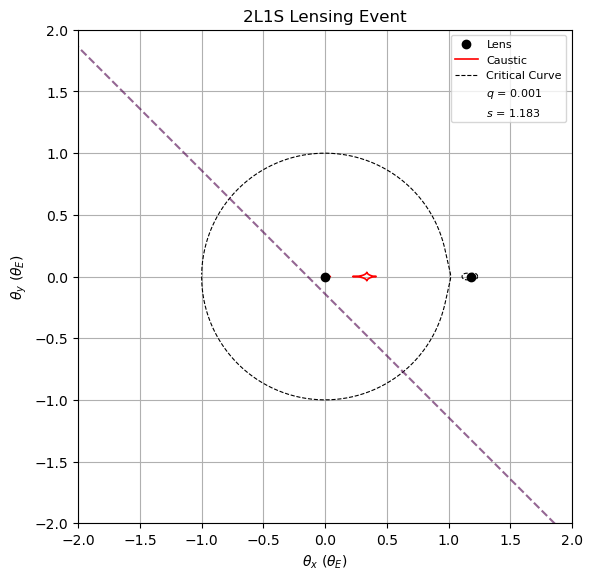

In [73]:
double_model.plot_caustic_critical_curves()

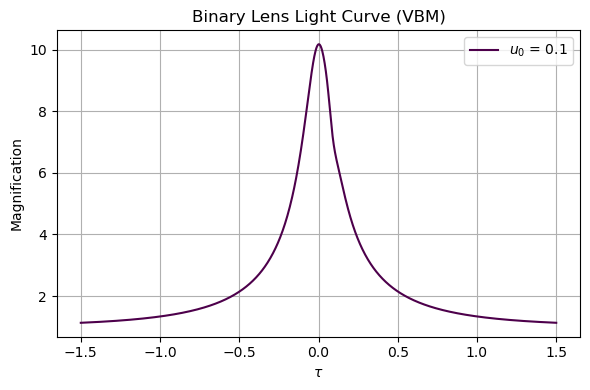

In [68]:
double_model.plot_light_curve()

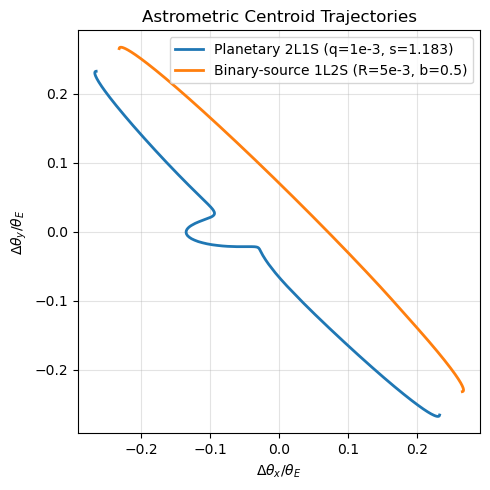

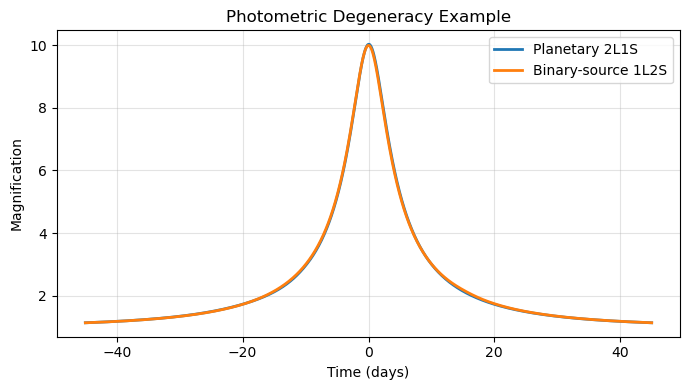

In [60]:
# --- shared, as you wrote ---
t0, tE = 0.0, 30.0
u0     = 0.10
rho    = 1.0e-3
alpha_deg = 315.0
alpha = np.deg2rad(alpha_deg)
t     = np.linspace(t0-1.5*tE, t0+1.5*tE, 1200)

# ---------- 2L1S ----------
q, s = 1e-3, 1.183
double_model = TwoLens1S(t0, tE, rho, [u0], q, s, alpha_deg, t_lc=t)

# photometry (2L1S)
A_2L1S = double_model.VBM.BinaryLightCurve(
    [np.log(s), np.log(q), u0, 0, np.log(rho), np.log(tE), t0], t
)[0]

# centroid (2L1S)
two_sys = double_model.systems[0]
dx_2 = two_sys['cent_x_lc'] - two_sys['y1s_lc']
dy_2 = two_sys['cent_y_lc'] - two_sys['y2s_lc']

# ---------- 1L2S (use same alpha) ----------
R = 5e-3
b = 0.5

u01, t01 = u0, t0
# PARALLEL (Han often shows perpendicular too—try both):
t02 = t01 + b*tE;  u02 = u01
# PERPENDICULAR (toggle these two lines instead of the two above):
# t02 = t01;        u02 = u01 + b

tau1 = (t - t01)/tE
tau2 = (t - t02)/tE
x1 = tau1*np.cos(alpha) - u01*np.sin(alpha)
y1 = tau1*np.sin(alpha) + u01*np.cos(alpha)
x2 = tau2*np.cos(alpha) - u02*np.sin(alpha)
y2 = tau2*np.sin(alpha) + u02*np.cos(alpha)

def A_u(u): return (u**2+2)/(u*np.sqrt(u**2+4))
def centroid_shift_single(uvec):
    u = np.linalg.norm(uvec, axis=-1, keepdims=True)
    return uvec/(u**2+2)

u1, u2 = np.hypot(x1,y1), np.hypot(x2,y2)
A1, A2 = A_u(u1), A_u(u2)
A_1L2S = (A1 + R*A2)/(1.0 + R)

s1 = np.stack([x1,y1], axis=-1); s2v = np.stack([x2,y2], axis=-1)
d1 = centroid_shift_single(s1);   d2 = centroid_shift_single(s2v)
c1 = s1 + d1;                     c2 = s2v + d2
F1, F2 = 1.0, R
Fl1, Fl2 = F1*A1, F2*A2
c_obs  = (Fl1[...,None]*c1 + Fl2[...,None]*c2)/(Fl1+Fl2)[...,None]
c_base = (F1*s1 + F2*s2v)/(F1+F2)
d_bin  = c_obs - c_base

# keep sign first; if mirrored vs 2L1S, flip both axes
dx_1, dy_1 = d_bin[...,0], d_bin[...,1]
# dx_1, dy_1 = -dx_1, -dy_1   # <- only if needed for sign convention

# ---------- plots ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot(dx_2, dy_2, lw=2, label="Planetary 2L1S (q=1e-3, s=1.183)")
plt.plot(dx_1, dy_1, lw=2, label="Binary-source 1L2S (R=5e-3, b=0.5)")
plt.axis('equal'); plt.grid(alpha=0.35)
plt.xlabel(r'$\Delta\theta_x/\theta_E$'); plt.ylabel(r'$\Delta\theta_y/\theta_E$')
plt.title('Astrometric Centroid Trajectories'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(t, A_2L1S, lw=2, label="Planetary 2L1S")
plt.plot(t, A_1L2S, lw=2, label="Binary-source 1L2S")
plt.grid(alpha=0.35); plt.xlabel('Time (days)'); plt.ylabel('Magnification')
plt.title('Photometric Degeneracy Example'); plt.legend(); plt.tight_layout(); plt.show()


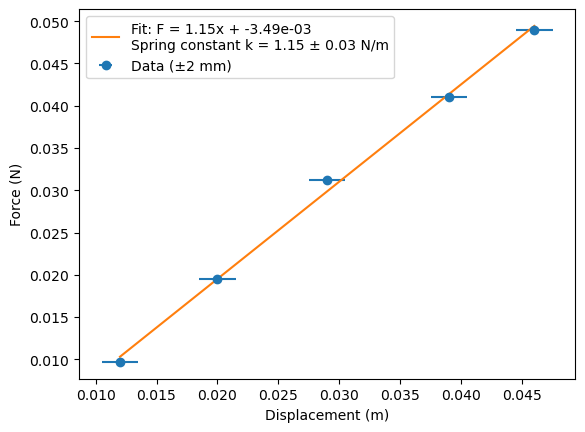

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# data
m = np.array([0.99, 1.99, 3.19, 4.19, 5.00]) * 1e-3   # kg
x = np.array([12, 20, 29, 39, 46]) * 1e-3             # m
dx = 1.5e-3                                              # m
g = 9.80
F = m * g                                              # N

# linear fit with uncertainty in x
coeffs, cov = np.polyfit(x, F, 1, cov=True)
k, b = coeffs
dk = np.sqrt(cov[0, 0])

# plot
plt.errorbar(x, F, xerr=dx, fmt='o', label='Data (±2 mm)')
plt.plot(x, k*x + b, label=f'Fit: F = {k:.2f}x + {b:.2e}\nSpring constant k = {k:.2f} ± {dk:.2f} N/m')
plt.xlabel('Displacement (m)')
plt.ylabel('Force (N)')
plt.legend()
plt.show()
